# Notebook 05 — Evaluation & Scaling

## Purpose

This notebook evaluates the three completed decoder-only Transformer models from the controlled pretraining experiment. It is designed as a **standalone analytical report**: the main body focuses on interpretation, scaling behavior, efficiency tradeoffs, qualitative behavior, and final conclusions, while raw collected measurements and audit evidence are kept in a separate appendix for reference.

### Experimental question

> **How does increasing Transformer capacity affect language-model performance when the dataset and training methodology are controlled, and what tradeoffs emerge between capability and computational efficiency?**

### Higher-level question

> **At what point does increasing model capacity produce diminishing returns when training data and compute are constrained?**

### Notebook 05 contract

- Models A, B, and C are frozen outputs from Notebook 04.
- No retraining, retuning, or hyperparameter changes occur here.
- Validation histories are used for comparative analysis.
- Controlled generation uses identical prompts and decoding settings across models.
- The official WikiText-103 test split remains sealed until the designated final-evaluation section.
- Raw measurements, provenance, and audit details are separated from interpretation in the appendix.

**Decision anchors:** D-084 through D-086.


## Reader Guide

The notebook is organized so its analytical sections can be referenced directly in the final presentation.

1. **Evaluation Framework** — what is being measured and why
2. **Frozen Experimental Inputs** — validated handoff from training
3. **Scaling in Language-Model Quality** — loss, perplexity, and learning behavior
4. **Scaling in Compute Cost** — training time, throughput, and memory
5. **Diminishing Returns** — marginal quality gained per unit of additional scale
6. **Controlled Qualitative Generation** — side-by-side behavior under fixed decoding
7. **Final Untouched-Test Evaluation** — one-time final generalization measurement
8. **Synthesis and Conclusions** — what the experiment supports and what it does not
9. **Appendix: Collected Data & Audit Evidence** — raw values, provenance, and reproducibility checks

> **Reading principle:** Sections 3–8 contain the analytical story. Section 9 contains the underlying collected evidence.


## Evaluation Design Decisions

Before inspecting the complete A/B/C validation histories, Notebook 05 freezes three rules so the analysis is not shaped after seeing the curves.

### D-084 — Evaluation Scope and Frozen-Input Contract

Models A/B/C, their checkpoints, training histories, architecture, tokenizer, corpus, optimizer settings, and training budget are immutable inputs. Notebook 05 performs evaluation only. Validation data may be analyzed; the official test split remains sealed until Section 7.

### D-085 — Evidence, Analysis, and Output Separation

Collected measurements and provenance are treated as evidence and kept separate from interpretation. The main body contains derived metrics, figures, analysis, and conclusions. Exact raw values and audit tables live in the appendix. Reusable outputs are written to `results/evaluation/` and `figures/evaluation/`.

### D-086 — Evaluation Metric and Figure Contract

Before viewing the full histories, the notebook commits to evaluating scale with fixed conventions: absolute and relative changes in loss/perplexity; parameter, time, and memory multipliers; marginal quality improvement per added million parameters, per added training minute, and per added GiB; and log-parameter views where analytically useful. Important figures must be reproducible, clearly labeled, independently understandable, and saved with stable filenames for later presentation use.


## 1. Evaluation Framework

The experiment isolates **model capacity** as the primary changing variable. Models A, B, and C were trained on the same tokenizer, same 20M-token training corpus, same context length, same optimizer, same learning-rate schedule, same effective batch size, same number of epochs, and the same total target-token exposures.

The evaluation therefore asks two related questions:

1. **Capability scaling:** How much does predictive language-model performance improve as parameter count increases?
2. **Efficiency scaling:** How much additional compute, memory, and elapsed time are required to obtain those gains?

The analysis will distinguish:

- **absolute improvement** — direct change in loss or perplexity;
- **relative improvement** — percentage change relative to the smaller model;
- **marginal improvement** — additional quality gained from the next increase in model size;
- **efficiency-adjusted improvement** — quality gained relative to added parameters, training time, or memory.

This distinction matters because a larger model can be objectively better while still delivering weaker **returns on additional scale**.


## 2. Frozen Experimental Inputs

This section validates the handoff from Notebook 04 and ingests the complete validation evidence under **D-087**. It intentionally does **not** interpret the measurements; analysis begins in Section 3.


In [1]:
import json
import os
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COLAB_ROOT = Path('/content')
REPO = COLAB_ROOT / 'foundation-model-from-scratch'

if not REPO.exists():
    subprocess.run([
        'git', 'clone',
        'https://github.com/traderjohnd/foundation-model-from-scratch.git',
        str(REPO),
    ], check=True)
else:
    subprocess.run([
        'git', '-C', str(REPO), 'pull', 'origin', 'main'
    ], check=True)

os.chdir(REPO)

SUMMARY_PATH = Path('results/training/production_scaling_summary.json')
EVALUATION_RESULTS_DIR = Path('results/evaluation')
EVALUATION_FIGURES_DIR = Path('figures/evaluation')

assert SUMMARY_PATH.exists(), f'Missing: {SUMMARY_PATH}'
EVALUATION_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
EVALUATION_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Notebook 05 bootstrap: PASS')
print('Repository:', REPO)
print('Evaluation results:', EVALUATION_RESULTS_DIR)
print('Evaluation figures:', EVALUATION_FIGURES_DIR)


Notebook 05 bootstrap: PASS
Repository: /content/foundation-model-from-scratch
Evaluation results: results/evaluation
Evaluation figures: figures/evaluation


In [2]:
with SUMMARY_PATH.open('r', encoding='utf-8') as f:
    production_summary = json.load(f)

assert production_summary['status'] == 'complete'
assert production_summary['training_protocol_frozen'] is True
assert production_summary['official_test_split_content_used'] is False
assert production_summary['optimizer_updates_per_model'] == 3_663
assert production_summary['target_exposures_per_model'] == 59_999_232
assert set(production_summary['models']) == {'A', 'B', 'C'}

for model_key, model_data in production_summary['models'].items():
    assert model_data['persistent_artifacts_verified'] is True

print('Frozen training handoff audit: PASS')
print('Official test split used before Notebook 05: NO')


Frozen training handoff audit: PASS
Official test split used before Notebook 05: NO


### Analysis boundary

The preceding cells establish provenance only. The model measurements are deliberately not discussed here. The exact collected values are reproduced in the appendix so the analytical sections can remain focused on interpretation rather than bookkeeping.


In [3]:
# Frozen analysis conventions (D-086)
ANALYSIS_CONTRACT = {
    'quality_metrics': ['validation_loss', 'validation_perplexity'],
    'comparisons': ['A_to_B', 'B_to_C', 'A_to_C'],
    'scale_views': [
        'absolute_change',
        'relative_percent_change',
        'parameter_multiplier',
        'training_time_multiplier',
        'memory_multiplier',
        'marginal_quality_per_added_million_parameters',
        'marginal_quality_per_added_training_minute',
        'marginal_quality_per_added_gib',
    ],
    'figure_requirements': {
        'stable_filename': True,
        'labeled_axes_with_units': True,
        'clear_title': True,
        'standalone_caption_or_context': True,
        'presentation_ready_export': True,
    },
}

print('D-086 analysis contract frozen before full-history ingestion: PASS')


D-086 analysis contract frozen before full-history ingestion: PASS


### D-087 — Validation-History Ingestion and Audit Contract

Before any scaling interpretation is performed, Notebook 05 ingests the complete persistent validation histories for Models A/B/C and validates them against the frozen Notebook 04 experiment.

The ingestion layer must prove:

- all three model history JSON files and run-summary JSON files exist;
- each artifact identifies the expected model;
- each model completed 3,663 optimizer updates and 3 full epochs;
- each model contains exactly 21 validation events at the frozen validation-update schedule;
- every validation event scores exactly 256,512 targets;
- the final validation event occurs at update 3,663;
- the minimum validation loss and its update reproduce the corresponding run summary;
- reported perplexity is consistent with `exp(validation loss)`;
- the run summary states that official test content was not used;
- A/B/C share the same frozen production protocol.

If any assertion fails, comparative analysis stops. The notebook does not repair, interpolate, or silently omit inconsistent evidence.

Normalized evidence and the ingestion audit are saved under `results/evaluation/evidence/`; analytical derivatives remain separate.


In [4]:
from google.colab import drive

DRIVE_ROOT = Path('/content/drive')
try:
    if not (DRIVE_ROOT / 'MyDrive').exists():
        drive.mount(str(DRIVE_ROOT), force_remount=False)
except Exception:
    drive.mount(str(DRIVE_ROOT), force_remount=True)

PERSISTENT_ROOT = DRIVE_ROOT / 'MyDrive' / 'foundation-model-from-scratch' / 'production'
PERSISTENT_TRAINING_RESULTS = PERSISTENT_ROOT / 'results' / 'training'
PERSISTENT_CHECKPOINTS = PERSISTENT_ROOT / 'checkpoints'

EVIDENCE_DIR = EVALUATION_RESULTS_DIR / 'evidence'
ANALYSIS_RESULTS_DIR = EVALUATION_RESULTS_DIR / 'analysis'
EVIDENCE_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

assert PERSISTENT_ROOT.exists(), f'Persistent production directory not found: {PERSISTENT_ROOT}'
print('Persistent production root:', PERSISTENT_ROOT)
print('Evidence output:', EVIDENCE_DIR)
print('Analysis output:', ANALYSIS_RESULTS_DIR)


Mounted at /content/drive
Persistent production root: /content/drive/MyDrive/foundation-model-from-scratch/production
Evidence output: results/evaluation/evidence
Analysis output: results/evaluation/analysis


In [5]:
import math

MODEL_KEYS = ('A', 'B', 'C')
EXPECTED_UPDATES = 3_663
EXPECTED_EPOCHS = 3
EXPECTED_VALIDATION_TARGETS = 256_512
EXPECTED_VALIDATION_UPDATES = tuple(sorted(set(range(200, EXPECTED_UPDATES + 1, 200)) | {1_221, 2_442, 3_663}))
assert len(EXPECTED_VALIDATION_UPDATES) == 21

def model_artifact_paths(model_key: str):
    key = model_key.lower()
    return {
        'history': PERSISTENT_TRAINING_RESULTS / f'model_{key}_training_history.json',
        'summary': PERSISTENT_TRAINING_RESULTS / f'model_{key}_run_summary.json',
        'best_checkpoint': PERSISTENT_CHECKPOINTS / f'model_{key}_best.pt',
        'latest_checkpoint': PERSISTENT_CHECKPOINTS / f'model_{key}_latest.pt',
    }

artifact_paths = {key: model_artifact_paths(key) for key in MODEL_KEYS}
for model_key, paths in artifact_paths.items():
    for artifact_name, artifact_path in paths.items():
        assert artifact_path.exists(), f'Model {model_key} missing {artifact_name}: {artifact_path}'
        assert artifact_path.stat().st_size > 0, f'Model {model_key} empty {artifact_name}: {artifact_path}'

print('Persistent artifact existence audit: PASS')


Persistent artifact existence audit: PASS


In [6]:
def load_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)

def audit_model_history(model_key: str):
    paths = artifact_paths[model_key]
    history_payload = load_json(paths['history'])
    summary = load_json(paths['summary'])

    assert history_payload['model_key'] == model_key
    assert summary['model_key'] == model_key
    assert summary['completed_updates'] == EXPECTED_UPDATES
    assert summary['completed_full_epochs'] == EXPECTED_EPOCHS
    assert summary['validation_events'] == 21
    assert summary['official_test_split_content_used'] is False

    validation_history = history_payload['validation_history']
    assert len(validation_history) == 21
    observed_updates = tuple(int(r['update']) for r in validation_history)
    assert observed_updates == EXPECTED_VALIDATION_UPDATES
    assert int(validation_history[-1]['update']) == EXPECTED_UPDATES

    for record in validation_history:
        assert int(record['validation_targets']) == EXPECTED_VALIDATION_TARGETS
        loss = float(record['validation_loss'])
        ppl = float(record['validation_perplexity'])
        assert math.isfinite(loss) and math.isfinite(ppl)
        assert math.isclose(ppl, math.exp(loss), rel_tol=1e-10, abs_tol=1e-10)

    best_record = min(validation_history, key=lambda r: float(r['validation_loss']))
    best_loss = float(best_record['validation_loss'])
    best_update = int(best_record['update'])
    assert math.isclose(best_loss, float(summary['best_validation_loss']), rel_tol=0.0, abs_tol=1e-12)
    assert best_update == int(summary['best_validation_update'])
    # Some production summaries were written before
    # best_validation_perplexity was stored explicitly. Perplexity is
    # deterministically derived from cross-entropy, so treat the field
    # as optional and verify it when present.
    derived_best_ppl = math.exp(best_loss)
    if 'best_validation_perplexity' in summary:
        assert math.isclose(
            derived_best_ppl,
            float(summary['best_validation_perplexity']),
            rel_tol=1e-10,
            abs_tol=1e-10,
        )

    summary['_derived_best_validation_perplexity'] = derived_best_ppl
    summary['_best_perplexity_source'] = (
        'stored_and_verified'
        if 'best_validation_perplexity' in summary
        else 'derived_from_best_validation_loss'
    )
    return history_payload, summary

history_payloads = {}
run_summaries = {}
for model_key in MODEL_KEYS:
    history_payloads[model_key], run_summaries[model_key] = audit_model_history(model_key)
    print(f'Model {model_key} history audit: PASS')


Model A history audit: PASS
Model B history audit: PASS
Model C history audit: PASS


In [7]:
# Cross-model frozen-protocol checks.
for model_key in MODEL_KEYS:
    summary = run_summaries[model_key]
    compact = production_summary['models'][model_key]
    assert int(summary['model_parameters']) == int(compact['parameters'])
    assert int(summary['completed_updates']) == production_summary['optimizer_updates_per_model']
    assert int(summary['total_target_exposures']) == production_summary['target_exposures_per_model']
    assert math.isclose(float(summary['peak_lr']), float(production_summary['peak_learning_rate']), rel_tol=0.0, abs_tol=0.0)
    assert math.isclose(float(summary['best_validation_loss']), float(compact['best_validation_loss']), rel_tol=0.0, abs_tol=5e-7)
    assert int(summary['best_validation_update']) == int(compact['best_validation_update'])
    assert math.isclose(
        float(summary['_derived_best_validation_perplexity']),
        float(compact['best_validation_perplexity']),
        rel_tol=0.0,
        abs_tol=5e-3,
    )

print('Cross-model frozen-protocol audit: PASS')


Cross-model frozen-protocol audit: PASS


In [8]:
# Normalize the validation evidence into one long-form table.
validation_rows = []
for model_key in MODEL_KEYS:
    for record in history_payloads[model_key]['validation_history']:
        validation_rows.append({
            'model': model_key,
            'epoch': int(record['epoch']),
            'update': int(record['update']),
            'validation_targets': int(record['validation_targets']),
            'validation_loss': float(record['validation_loss']),
            'validation_perplexity': float(record['validation_perplexity']),
        })

validation_evidence = pd.DataFrame(validation_rows).sort_values(['model', 'update']).reset_index(drop=True)
assert len(validation_evidence) == 63
assert validation_evidence.groupby('model').size().to_dict() == {'A': 21, 'B': 21, 'C': 21}

validation_evidence_path = EVIDENCE_DIR / 'validation_history_canonical.csv'
validation_evidence.to_csv(validation_evidence_path, index=False)
validation_evidence


,model,epoch,update,validation_targets,validation_loss,validation_perplexity
0,A,1,200,256512,5.816321,335.734458
1,A,1,400,256512,5.199272,181.140242
2,A,1,600,256512,4.913573,136.124855
3,A,1,800,256512,4.729249,113.210457
4,A,1,1000,256512,4.552368,94.856773
...,...,...,...,...,...,...
58,C,3,3000,256512,3.744919,42.305588
59,C,3,3200,256512,3.719281,41.234719
60,C,3,3400,256512,3.699645,40.432941
61,C,3,3600,256512,3.685923,39.881898


In [9]:
# Persist a compact machine-readable audit record.
history_audit = {
    'decision_id': 'D-087',
    'status': 'pass',
    'models': {},
    'expected_validation_updates': list(EXPECTED_VALIDATION_UPDATES),
    'expected_validation_events_per_model': 21,
    'expected_validation_targets_per_event': EXPECTED_VALIDATION_TARGETS,
    'official_test_split_content_used_before_analysis': False,
}
for model_key in MODEL_KEYS:
    summary = run_summaries[model_key]
    history_audit['models'][model_key] = {
        'completed_updates': int(summary['completed_updates']),
        'completed_full_epochs': int(summary['completed_full_epochs']),
        'validation_events': int(summary['validation_events']),
        'best_validation_loss': float(summary['best_validation_loss']),
        'best_validation_perplexity': float(summary['_derived_best_validation_perplexity']),
        'best_validation_perplexity_source': summary['_best_perplexity_source'],
        'best_validation_update': int(summary['best_validation_update']),
    }

audit_path = EVIDENCE_DIR / 'validation_history_ingestion_audit.json'
with audit_path.open('w', encoding='utf-8') as f:
    json.dump(history_audit, f, indent=2, allow_nan=False)

print('D-087 VALIDATION-HISTORY INGESTION: PASS')
print('Canonical evidence:', validation_evidence_path)
print('Audit record:', audit_path)
print('Rows:', len(validation_evidence))


D-087 VALIDATION-HISTORY INGESTION: PASS
Canonical evidence: results/evaluation/evidence/validation_history_canonical.csv
Audit record: results/evaluation/evidence/validation_history_ingestion_audit.json
Rows: 63


### Evidence boundary after D-087

At this point the notebook has only **verified and normalized collected evidence**. No conclusion has yet been drawn about whether scaling improved quality, how large any improvement was, or whether returns diminished. Those questions begin in Section 3.


## 3. Scaling in Language-Model Quality

With the evidence layer verified, the analysis now asks how predictive language-model quality changed as model capacity increased under the **same tokenizer, corpus, optimizer schedule, update count, and target-token exposure budget**.

This section deliberately evaluates **quality only**. Training time, throughput, memory, and efficiency-adjusted returns are deferred to Sections 4 and 5 so capability and cost are not conflated.

### D-088 — Quality-Scaling Analysis

Quality scaling is evaluated from two complementary views:

1. **Learning trajectory:** validation loss and perplexity across the 21 common validation checkpoints.
2. **Final/best achieved quality:** absolute and relative endpoint differences among Models A, B, and C.

Because all three models achieved their best validation result at the final update, the endpoint and best-checkpoint comparisons coincide for this experiment. The notebook nevertheless retains the best-checkpoint terminology because that was the frozen selection rule from training.


### 3.1 Validation Learning Curves

The first comparison examines the complete validation trajectories rather than only the final scores. A model that ends lower but learns erratically would tell a different story from one that remains consistently better across training.


In [10]:
# D-088: canonical learning-curve data derived from the audited evidence layer.
quality_curve_data = validation_evidence.copy()

assert set(quality_curve_data['model']) == {'A', 'B', 'C'}
assert quality_curve_data.groupby('model').size().eq(21).all()
assert quality_curve_data.groupby('model')['update'].apply(tuple).nunique() == 1

quality_curve_data.head()


,model,epoch,update,validation_targets,validation_loss,validation_perplexity
0,A,1,200,256512,5.816321,335.734458
1,A,1,400,256512,5.199272,181.140242
2,A,1,600,256512,4.913573,136.124855
3,A,1,800,256512,4.729249,113.210457
4,A,1,1000,256512,4.552368,94.856773


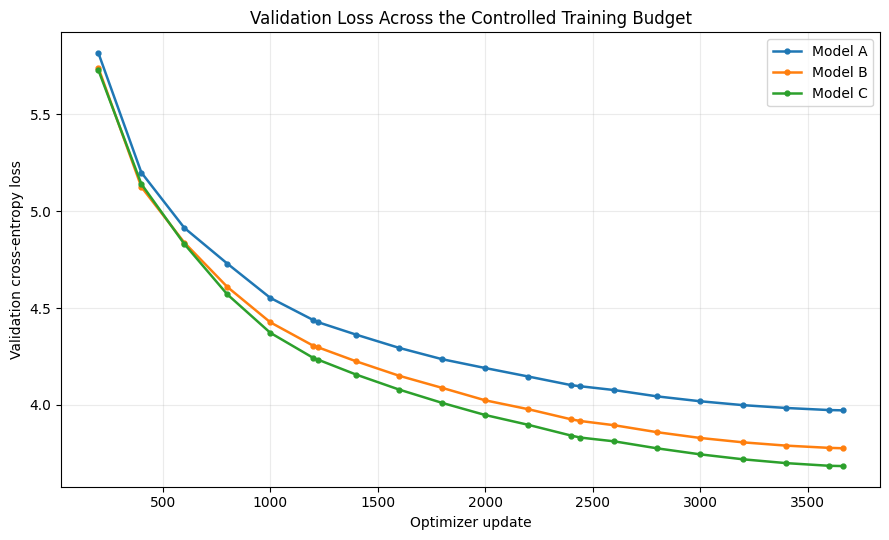

Saved: figures/evaluation/fig_01_validation_loss_learning_curves.png


In [11]:
# Figure 01 — validation loss across the shared training schedule.
fig, ax = plt.subplots(figsize=(9, 5.5))

for model_key in MODEL_KEYS:
    model_rows = quality_curve_data[quality_curve_data['model'] == model_key]
    ax.plot(
        model_rows['update'],
        model_rows['validation_loss'],
        marker='o',
        markersize=3.5,
        linewidth=1.8,
        label=f'Model {model_key}',
    )

ax.set_title('Validation Loss Across the Controlled Training Budget')
ax.set_xlabel('Optimizer update')
ax.set_ylabel('Validation cross-entropy loss')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

fig01_path = EVALUATION_FIGURES_DIR / 'fig_01_validation_loss_learning_curves.png'
fig.savefig(fig01_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved:', fig01_path)


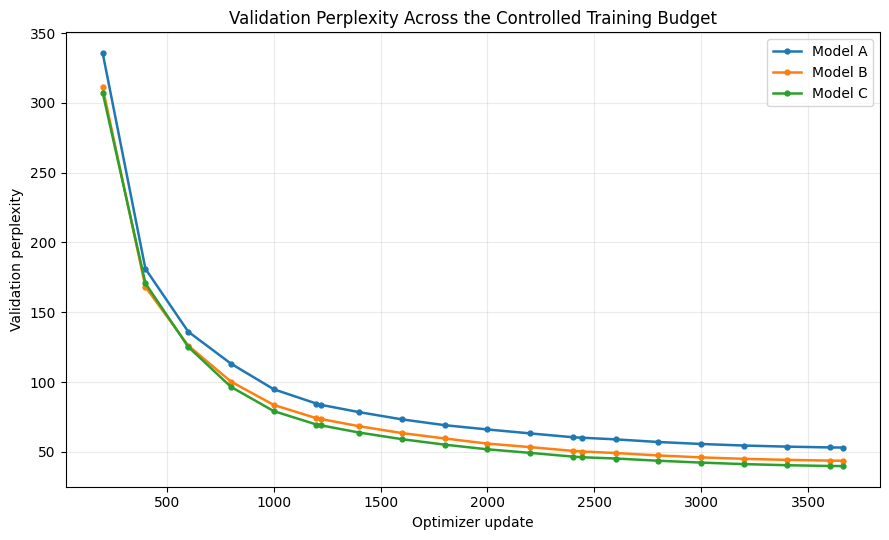

Saved: figures/evaluation/fig_02_validation_perplexity_learning_curves.png


In [12]:
# Figure 02 — validation perplexity across the same checkpoints.
fig, ax = plt.subplots(figsize=(9, 5.5))

for model_key in MODEL_KEYS:
    model_rows = quality_curve_data[quality_curve_data['model'] == model_key]
    ax.plot(
        model_rows['update'],
        model_rows['validation_perplexity'],
        marker='o',
        markersize=3.5,
        linewidth=1.8,
        label=f'Model {model_key}',
    )

ax.set_title('Validation Perplexity Across the Controlled Training Budget')
ax.set_xlabel('Optimizer update')
ax.set_ylabel('Validation perplexity')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

fig02_path = EVALUATION_FIGURES_DIR / 'fig_02_validation_perplexity_learning_curves.png'
fig.savefig(fig02_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved:', fig02_path)


### 3.2 Best Validation Quality by Model

The next table summarizes the best achieved held-out quality for each model. Because lower cross-entropy and lower perplexity are better, improvement is reported as the reduction obtained when moving to a larger model.


In [13]:
quality_endpoint_rows = []

for model_key in MODEL_KEYS:
    summary = run_summaries[model_key]
    quality_endpoint_rows.append({
        'Model': model_key,
        'Parameters': int(summary['model_parameters']),
        'Parameters (M)': int(summary['model_parameters']) / 1_000_000,
        'Best validation loss': float(summary['best_validation_loss']),
        'Best validation perplexity': float(summary['_derived_best_validation_perplexity']),
        'Best update': int(summary['best_validation_update']),
    })

quality_endpoints = pd.DataFrame(quality_endpoint_rows).set_index('Model')
quality_endpoints


,Parameters,Parameters (M),Best validation loss,Best validation perplexity,Best update
Model,,,,,
A,7407872,7.407872,3.972054,53.093487,3663
B,16913280,16.913280,3.776427,43.659777,3663
C,33497600,33.497600,3.684501,39.825232,3663


In [14]:
def quality_change(smaller: str, larger: str):
    s = quality_endpoints.loc[smaller]
    l = quality_endpoints.loc[larger]

    loss_reduction = float(s['Best validation loss'] - l['Best validation loss'])
    ppl_reduction = float(s['Best validation perplexity'] - l['Best validation perplexity'])

    return {
        'Comparison': f'{smaller} → {larger}',
        'Parameter multiplier': float(l['Parameters'] / s['Parameters']),
        'Added parameters (M)': float((l['Parameters'] - s['Parameters']) / 1_000_000),
        'Loss reduction': loss_reduction,
        'Loss reduction (%)': float(100 * loss_reduction / s['Best validation loss']),
        'Perplexity reduction': ppl_reduction,
        'Perplexity reduction (%)': float(100 * ppl_reduction / s['Best validation perplexity']),
    }

quality_changes = pd.DataFrame([
    quality_change('A', 'B'),
    quality_change('B', 'C'),
    quality_change('A', 'C'),
]).set_index('Comparison')

quality_changes


,Parameter multiplier,Added parameters (M),Loss reduction,Loss reduction (%),Perplexity reduction,Perplexity reduction (%)
Comparison,,,,,,
A → B,2.283150,9.505408,0.195627,4.925084,9.433709,17.768111
B → C,1.980550,16.584320,0.091927,2.434220,3.834545,8.782786
A → C,4.521892,26.089728,0.287554,7.239417,13.268254,24.990362


In [15]:
# Persist the Section 3 numerical outputs separately from source evidence.
quality_endpoints_path = ANALYSIS_RESULTS_DIR / 'quality_endpoints.csv'
quality_changes_path = ANALYSIS_RESULTS_DIR / 'quality_scaling_changes.csv'

quality_endpoints.to_csv(quality_endpoints_path)
quality_changes.to_csv(quality_changes_path)

print('Saved:', quality_endpoints_path)
print('Saved:', quality_changes_path)


Saved: results/evaluation/analysis/quality_endpoints.csv
Saved: results/evaluation/analysis/quality_scaling_changes.csv


### 3.3 Interpretation — What Scaling Bought in Quality

The executed learning curves and endpoint comparisons support five conclusions about **quality scaling alone**.

**1. Larger capacity produced better held-out language-model performance.**  
At the final/best checkpoint, validation loss falls from **3.9721 → 3.7764 → 3.6845** as the models scale from A to B to C. Validation perplexity correspondingly falls from **53.09 → 43.66 → 39.83**. Under the controlled training protocol, the endpoint relationship is therefore monotonic: the larger model is better on the held-out next-token prediction objective.

**2. The capacity advantage appears during training, not only at the endpoint.**  
Model A remains visibly above the larger models through the learning curves. Models B and C are very close during the earliest checkpoints, but Model C separates below Model B as training progresses and finishes with the best validation result. The result is therefore not simply a last-checkpoint artifact.

**3. None of the three models exhausted the fixed training budget.**  
All three models achieve their best validation loss at the final optimizer update (**3,663**). There is no observed validation deterioration before training stops. This means the experiment does **not** establish that any model reached its best possible performance; it establishes only the best performance observed under the frozen three-epoch / ~60M-target-exposure budget.

**4. The quality gain compresses substantially at the second scaling step.**  
Moving from Model A to B reduces validation loss by **0.1956 (4.93%)** and perplexity by **9.43 (17.77%)**. Moving from B to C reduces loss by only **0.0919 (2.43%)** and perplexity by **3.83 (8.78%)**. Thus the B→C loss improvement is about **47%** of the A→B improvement, and the perplexity improvement is about **41%**, even though B→C adds more parameters in absolute terms.

**5. This is an early quality-side indication of diminishing returns, not yet the full efficiency conclusion.**  
Model C is objectively better than Model B, so additional capacity is still useful. But the incremental predictive gain is already shrinking. Whether that smaller gain is justified by the additional training time, memory, and throughput cost is intentionally deferred to Sections 4 and 5.

> **Section 3 conclusion:** Within this controlled single-seed experiment, increasing Transformer capacity improves validation language-model quality, but the incremental improvement contracts materially at the largest scaling step. The experiment therefore shows continued benefit from scale **and** an emerging diminishing-return pattern under the fixed data/training budget.

**Interpretive limitation.** These results describe one controlled seed and one small-model scaling ladder on a fixed 20M-token corpus. They support conclusions about this experiment; they should not be presented as a general empirical scaling law without additional model sizes, token budgets, and/or repeated seeds.

_Perplexity is `exp(cross-entropy)`, so loss and perplexity are two views of the same predictive objective rather than independent measures of capability._


## 4. Scaling in Compute Cost

Section 3 established what additional model capacity bought in predictive quality. This section isolates the other side of the experiment: **what additional scale cost to train under the same production protocol on the same Tesla T4**.

### D-089 — Compute-Cost Scaling Analysis

The compute comparison separates **directly measured** quantities from **derived** quantities:

- **Directly measured:** production wall-clock time and peak allocated GPU memory.
- **Derived from recorded measurements:** GPU-hours, optimizer updates per second, and effective target-exposures per second.

All three models completed the same 3,663 optimizer updates and the same 59,999,232 target-token exposures. Therefore, differences in elapsed time and throughput primarily reflect the cost of executing larger model architectures under the fixed experimental workload.

> **Important measurement note:** `target-exposures/sec` below is an end-to-end effective throughput computed from total recorded target exposures divided by total production wall time. Because wall time includes periodic validation and checkpoint overhead, it should not be interpreted as a pure training-kernel benchmark.


### 4.1 Compute and Memory Summary

The first table places the directly measured resource values beside the derived throughput measures.


In [16]:
TOTAL_UPDATES = int(production_summary['optimizer_updates_per_model'])
TOTAL_TARGET_EXPOSURES = int(production_summary['target_exposures_per_model'])

compute_rows = []
for model_key in MODEL_KEYS:
    compact = production_summary['models'][model_key]
    wall_minutes = float(compact['wall_time_minutes'])
    wall_seconds = wall_minutes * 60.0

    compute_rows.append({
        'Model': model_key,
        'Parameters': int(compact['parameters']),
        'Parameters (M)': int(compact['parameters']) / 1_000_000,
        'Wall time (min)': wall_minutes,
        'GPU-hours': wall_minutes / 60.0,
        'Peak GPU memory (GiB)': float(compact['peak_gpu_memory_gib']),
        'Updates/sec': TOTAL_UPDATES / wall_seconds,
        'Effective target exposures/sec': TOTAL_TARGET_EXPOSURES / wall_seconds,
    })

compute_summary = pd.DataFrame(compute_rows).set_index('Model')
compute_summary


,Parameters,Parameters (M),Wall time (min),GPU-hours,Peak GPU memory (GiB),Updates/sec,Effective target exposures/sec
Model,,,,,,,
A,7407872,7.407872,11.78,0.196333,4.94,5.182513,84888.556876
B,16913280,16.913280,23.55,0.392500,7.29,2.592357,42462.301486
C,33497600,33.497600,42.22,0.703667,10.62,1.445997,23685.153955


### 4.2 Relative Cost of Scaling

The next comparison expresses how much the resource burden changes from A→B, B→C, and A→C. Ratios are useful here because all three runs processed the same optimization workload.


In [17]:
def compute_change(smaller: str, larger: str):
    s = compute_summary.loc[smaller]
    l = compute_summary.loc[larger]

    return {
        'Comparison': f'{smaller} → {larger}',
        'Parameter multiplier': float(l['Parameters'] / s['Parameters']),
        'Wall-time multiplier': float(l['Wall time (min)'] / s['Wall time (min)']),
        'Added wall time (min)': float(l['Wall time (min)'] - s['Wall time (min)']),
        'Peak-memory multiplier': float(l['Peak GPU memory (GiB)'] / s['Peak GPU memory (GiB)']),
        'Added peak memory (GiB)': float(l['Peak GPU memory (GiB)'] - s['Peak GPU memory (GiB)']),
        'Throughput retained (%)': float(100 * l['Effective target exposures/sec'] / s['Effective target exposures/sec']),
        'Throughput reduction (%)': float(100 * (1 - l['Effective target exposures/sec'] / s['Effective target exposures/sec'])),
    }

compute_changes = pd.DataFrame([
    compute_change('A', 'B'),
    compute_change('B', 'C'),
    compute_change('A', 'C'),
]).set_index('Comparison')

compute_changes


,Parameter multiplier,Wall-time multiplier,Added wall time (min),Peak-memory multiplier,Added peak memory (GiB),Throughput retained (%),Throughput reduction (%)
Comparison,,,,,,,
A → B,2.283150,1.999151,11.77,1.475709,2.35,50.021231,49.978769
B → C,1.980550,1.792781,18.67,1.456790,3.33,55.779252,44.220748
A → C,4.521892,3.584041,30.44,2.149798,5.68,27.901468,72.098532


### 4.3 Training-Time Scaling


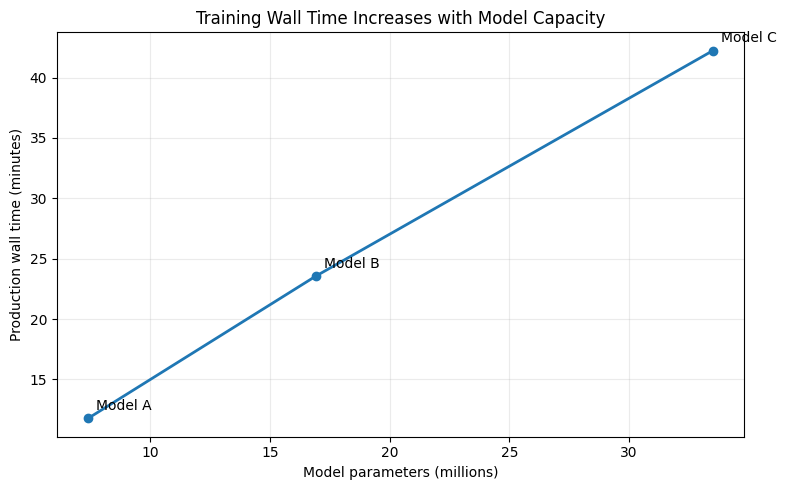

Saved: figures/evaluation/fig_03_training_wall_time_vs_parameters.png


In [18]:
# Figure 03 — end-to-end production wall time by model size.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    compute_summary['Parameters (M)'],
    compute_summary['Wall time (min)'],
    marker='o',
    linewidth=2,
)

for model_key, row in compute_summary.iterrows():
    ax.annotate(
        f'Model {model_key}',
        (row['Parameters (M)'], row['Wall time (min)']),
        xytext=(6, 6),
        textcoords='offset points',
    )

ax.set_title('Training Wall Time Increases with Model Capacity')
ax.set_xlabel('Model parameters (millions)')
ax.set_ylabel('Production wall time (minutes)')
ax.grid(alpha=0.25)
fig.tight_layout()

fig03_path = EVALUATION_FIGURES_DIR / 'fig_03_training_wall_time_vs_parameters.png'
fig.savefig(fig03_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', fig03_path)


### 4.4 GPU-Memory Scaling


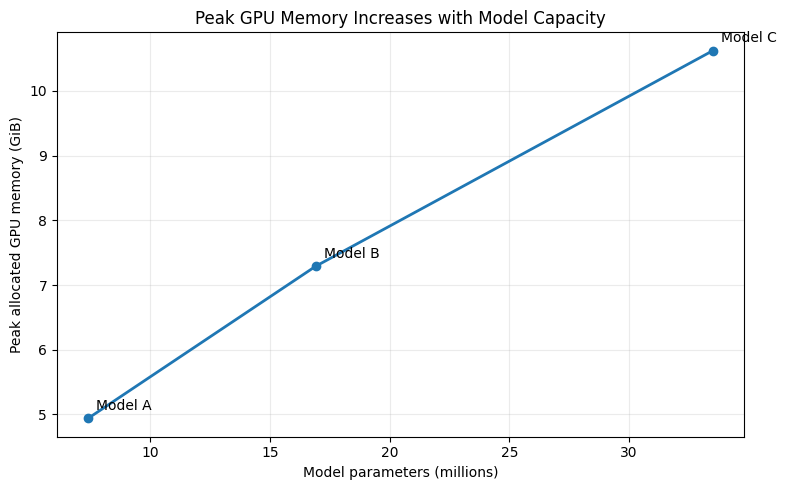

Saved: figures/evaluation/fig_04_peak_gpu_memory_vs_parameters.png


In [19]:
# Figure 04 — measured peak GPU memory by model size.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    compute_summary['Parameters (M)'],
    compute_summary['Peak GPU memory (GiB)'],
    marker='o',
    linewidth=2,
)

for model_key, row in compute_summary.iterrows():
    ax.annotate(
        f'Model {model_key}',
        (row['Parameters (M)'], row['Peak GPU memory (GiB)']),
        xytext=(6, 6),
        textcoords='offset points',
    )

ax.set_title('Peak GPU Memory Increases with Model Capacity')
ax.set_xlabel('Model parameters (millions)')
ax.set_ylabel('Peak allocated GPU memory (GiB)')
ax.grid(alpha=0.25)
fig.tight_layout()

fig04_path = EVALUATION_FIGURES_DIR / 'fig_04_peak_gpu_memory_vs_parameters.png'
fig.savefig(fig04_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', fig04_path)


### 4.5 Effective Throughput Scaling


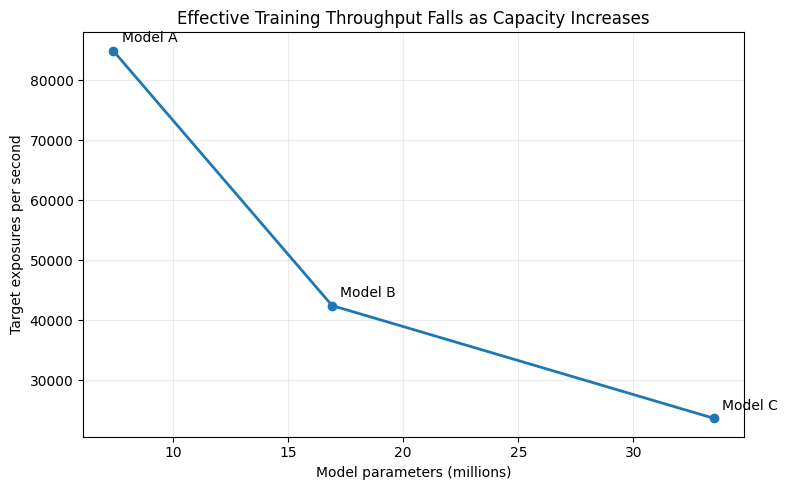

Saved: figures/evaluation/fig_05_effective_throughput_vs_parameters.png


In [20]:
# Figure 05 — effective end-to-end target-exposure throughput.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    compute_summary['Parameters (M)'],
    compute_summary['Effective target exposures/sec'],
    marker='o',
    linewidth=2,
)

for model_key, row in compute_summary.iterrows():
    ax.annotate(
        f'Model {model_key}',
        (row['Parameters (M)'], row['Effective target exposures/sec']),
        xytext=(6, 6),
        textcoords='offset points',
    )

ax.set_title('Effective Training Throughput Falls as Capacity Increases')
ax.set_xlabel('Model parameters (millions)')
ax.set_ylabel('Target exposures per second')
ax.grid(alpha=0.25)
fig.tight_layout()

fig05_path = EVALUATION_FIGURES_DIR / 'fig_05_effective_throughput_vs_parameters.png'
fig.savefig(fig05_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', fig05_path)


In [21]:
# Persist Section 4 analytical outputs.
compute_summary_path = ANALYSIS_RESULTS_DIR / 'compute_scaling_summary.csv'
compute_changes_path = ANALYSIS_RESULTS_DIR / 'compute_scaling_changes.csv'

compute_summary.to_csv(compute_summary_path)
compute_changes.to_csv(compute_changes_path)

print('Saved:', compute_summary_path)
print('Saved:', compute_changes_path)


Saved: results/evaluation/analysis/compute_scaling_summary.csv
Saved: results/evaluation/analysis/compute_scaling_changes.csv


### 4.6 Interpretation — What Scaling Cost

The executed resource measurements show that additional model capacity produced a substantial and measurable training-cost increase on the same Tesla T4.

**1. End-to-end training time rose rapidly with model size.**  
Production wall time increased from **11.78 minutes (A)** to **23.55 minutes (B)** to **42.22 minutes (C)**. A→B therefore required almost exactly **2.00×** the wall time, while B→C required another **1.79×**. Across the full A→C range, parameter count increased **4.52×** while wall time increased **3.58×**.

**2. Peak GPU memory increased materially, but more slowly than parameter count.**  
Peak allocated memory rose from **4.94 GiB → 7.29 GiB → 10.62 GiB**. A→B increased peak memory by **2.35 GiB (1.48×)** and B→C by **3.33 GiB (1.46×)**. Across A→C, parameters increased 4.52× while measured peak memory increased only **2.15×**, indicating sub-proportional memory growth over this tested range.

**3. Effective end-to-end throughput fell sharply as capacity increased.**  
With the same total target exposures for every model, effective throughput declined from approximately **84,889 → 42,462 → 23,685 target exposures/sec**. Model B retained about **50.0%** of Model A's throughput, while Model C retained about **55.8%** of Model B's and only **27.9%** of Model A's.

**4. Throughput is a derived view of the same elapsed-time burden, not an independent benchmark.**  
Because every model processed the same total target exposures, the effective throughput metric is mathematically tied to total wall time. It is still useful operationally, but it should not be presented as a separate hardware benchmark. The recorded wall time also includes periodic validation and checkpoint overhead.

**5. Within the tested range, elapsed time becomes the more visible practical constraint before memory capacity is exhausted.**  
All three models fit the full 32-sequence physical batch on the T4, and Model C's measured peak allocation was **10.62 GiB**. No tested model encountered a memory-capacity failure, while end-to-end runtime increased to more than 3.5× the Model A baseline. This does not prove memory would remain secondary at larger scales; it describes the constraint observed within this model family.

> **Section 4 conclusion:** Scaling the model family increased quality, but it also imposed substantial training-time and memory costs. Over the tested range, wall time grew strongly, peak memory grew sub-proportionally to parameter count, and effective end-to-end throughput fell by roughly 72% from Model A to Model C.

**Measurement limitation.** These are single production runs on one Tesla T4 rather than repeated hardware benchmarks. Wall-clock values should therefore be treated as experiment-level resource measurements, not universal performance specifications for these architectures.


## 5. Diminishing Returns

Sections 3 and 4 deliberately separated **quality** from **cost**. This section combines them to answer the project's higher-level question: when the model becomes larger, how much additional predictive improvement is obtained for the additional resources consumed?

### D-090 — Marginal Return Analysis

With only three model sizes, this notebook does **not** fit or claim a universal scaling law. Instead, diminishing returns are evaluated through the two observed incremental scale steps: **A→B** and **B→C**.

The precommitted D-086 metrics are used directly:

- validation-loss reduction per added million parameters;
- perplexity reduction per added million parameters;
- validation-loss and perplexity reduction per added training minute;
- validation-loss and perplexity reduction per added GiB of peak GPU memory.

The central question is not whether Model C is better—it is—but whether the **marginal return on the additional scale** is smaller than in the preceding A→B step.


### 5.1 Marginal Quality Gain per Added Resource


In [22]:
marginal_rows = []

for smaller, larger in [('A', 'B'), ('B', 'C')]:
    q = quality_changes.loc[f'{smaller} → {larger}']
    c = compute_changes.loc[f'{smaller} → {larger}']

    added_params_m = float(q['Added parameters (M)'])
    added_minutes = float(c['Added wall time (min)'])
    added_memory = float(c['Added peak memory (GiB)'])
    loss_gain = float(q['Loss reduction'])
    ppl_gain = float(q['Perplexity reduction'])

    marginal_rows.append({
        'Comparison': f'{smaller} → {larger}',
        'Added parameters (M)': added_params_m,
        'Added wall time (min)': added_minutes,
        'Added peak memory (GiB)': added_memory,
        'Loss reduction': loss_gain,
        'Perplexity reduction': ppl_gain,
        'Loss reduction / added M params': loss_gain / added_params_m,
        'PPL reduction / added M params': ppl_gain / added_params_m,
        'Loss reduction / added minute': loss_gain / added_minutes,
        'PPL reduction / added minute': ppl_gain / added_minutes,
        'Loss reduction / added GiB': loss_gain / added_memory,
        'PPL reduction / added GiB': ppl_gain / added_memory,
    })

marginal_returns = pd.DataFrame(marginal_rows).set_index('Comparison')
marginal_returns


,Added parameters (M),Added wall time (min),Added peak memory (GiB),Loss reduction,Perplexity reduction,Loss reduction / added M params,PPL reduction / added M params,Loss reduction / added minute,PPL reduction / added minute,Loss reduction / added GiB,PPL reduction / added GiB
Comparison,,,,,,,,,,,
A → B,9.505408,11.77,2.35,0.195627,9.433709,0.020581,0.992457,0.016621,0.801505,0.083246,4.014344
B → C,16.584320,18.67,3.33,0.091927,3.834545,0.005543,0.231215,0.004924,0.205385,0.027606,1.151515


### 5.2 How Much Marginal Efficiency Survived the Second Scale Step?

The B→C marginal efficiency is expressed as a percentage of the A→B marginal efficiency. A value of 100% would mean no deterioration in marginal return; lower values indicate stronger diminishing returns.


In [23]:
ab = marginal_returns.loc['A → B']
bc = marginal_returns.loc['B → C']

efficiency_retention = pd.DataFrame({
    'Resource basis': ['Added parameters', 'Added training time', 'Added peak GPU memory'],
    'Loss-efficiency retained (%)': [
        100 * bc['Loss reduction / added M params'] / ab['Loss reduction / added M params'],
        100 * bc['Loss reduction / added minute'] / ab['Loss reduction / added minute'],
        100 * bc['Loss reduction / added GiB'] / ab['Loss reduction / added GiB'],
    ],
    'Perplexity-efficiency retained (%)': [
        100 * bc['PPL reduction / added M params'] / ab['PPL reduction / added M params'],
        100 * bc['PPL reduction / added minute'] / ab['PPL reduction / added minute'],
        100 * bc['PPL reduction / added GiB'] / ab['PPL reduction / added GiB'],
    ],
}).set_index('Resource basis')

efficiency_retention


,Loss-efficiency retained (%),Perplexity-efficiency retained (%)
Resource basis,,
Added parameters,26.933034,23.297237
Added training time,29.624043,25.624977
Added peak GPU memory,33.161626,28.685007


### 5.3 Quality–Cost Frontier


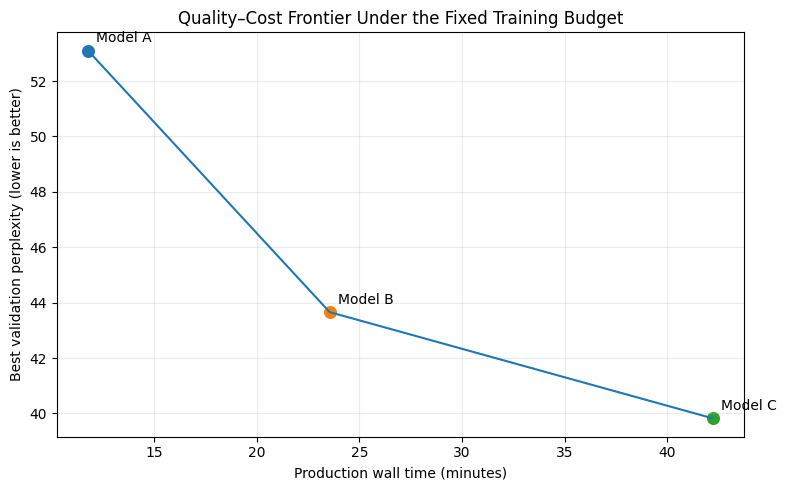

Saved: figures/evaluation/fig_06_quality_cost_frontier.png


In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

for model_key in MODEL_KEYS:
    x = compute_summary.loc[model_key, 'Wall time (min)']
    y = quality_endpoints.loc[model_key, 'Best validation perplexity']
    ax.scatter(x, y, s=70)
    ax.annotate(f'Model {model_key}', (x, y), xytext=(6, 6), textcoords='offset points')

ax.plot(
    [compute_summary.loc[k, 'Wall time (min)'] for k in MODEL_KEYS],
    [quality_endpoints.loc[k, 'Best validation perplexity'] for k in MODEL_KEYS],
    linewidth=1.5,
)
ax.set_title('Quality–Cost Frontier Under the Fixed Training Budget')
ax.set_xlabel('Production wall time (minutes)')
ax.set_ylabel('Best validation perplexity (lower is better)')
ax.grid(alpha=0.25)
fig.tight_layout()

fig06_path = EVALUATION_FIGURES_DIR / 'fig_06_quality_cost_frontier.png'
fig.savefig(fig06_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', fig06_path)


### 5.4 Marginal Perplexity Efficiency Retained


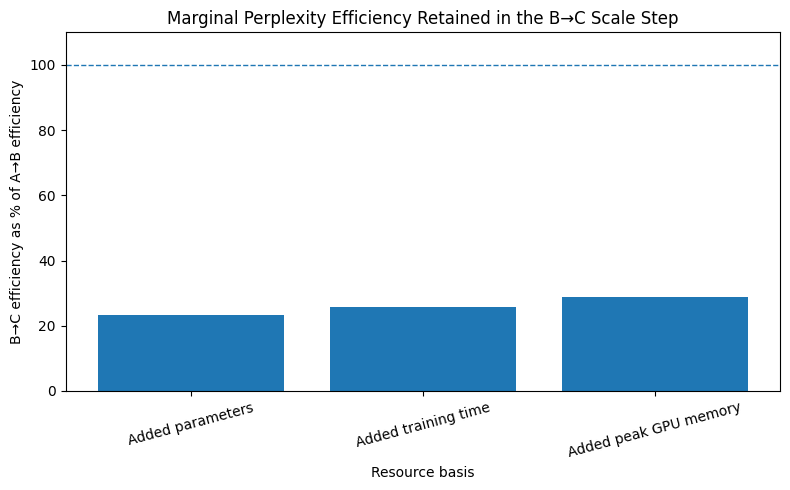

Saved: figures/evaluation/fig_07_marginal_efficiency_retained.png


In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_data = efficiency_retention['Perplexity-efficiency retained (%)']
ax.bar(plot_data.index, plot_data.values)
ax.axhline(100, linewidth=1, linestyle='--')
ax.set_title('Marginal Perplexity Efficiency Retained in the B→C Scale Step')
ax.set_xlabel('Resource basis')
ax.set_ylabel('B→C efficiency as % of A→B efficiency')
ax.set_ylim(0, 110)
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()

fig07_path = EVALUATION_FIGURES_DIR / 'fig_07_marginal_efficiency_retained.png'
fig.savefig(fig07_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', fig07_path)


In [26]:
marginal_returns_path = ANALYSIS_RESULTS_DIR / 'marginal_returns.csv'
efficiency_retention_path = ANALYSIS_RESULTS_DIR / 'marginal_efficiency_retention.csv'

marginal_returns.to_csv(marginal_returns_path)
efficiency_retention.to_csv(efficiency_retention_path)

print('Saved:', marginal_returns_path)
print('Saved:', efficiency_retention_path)


Saved: results/evaluation/analysis/marginal_returns.csv
Saved: results/evaluation/analysis/marginal_efficiency_retention.csv


### 5.5 Interpretation — Diminishing Returns Are Now Directly Observable

The marginal-return analysis confirms that the second capacity increase still improves predictive quality, but does so at substantially weaker efficiency than the first.

**1. The B→C step produces much less quality improvement per added parameter.**  
A→B reduces validation loss by **0.1956** and perplexity by **9.43** while adding about **9.51M parameters**. B→C reduces loss by only **0.0919** and perplexity by **3.83** while adding about **16.58M parameters**. On a per-added-million-parameter basis, B→C retains only **26.9%** of A→B's loss efficiency and **23.3%** of its perplexity efficiency.

**2. The same contraction remains when training time is the denominator.**  
A→B gains about **0.0166 loss reduction per added training minute**, compared with only **0.00492** for B→C. The second step retains **29.6%** of the first step's loss efficiency and **25.6%** of its perplexity efficiency per added minute.

**3. The result is not an artifact of choosing parameters or time as the cost basis.**  
When added peak GPU memory is used instead, B→C still retains only **33.2%** of A→B's loss efficiency and **28.7%** of its perplexity efficiency. The diminishing-return signal therefore appears across all three precommitted resource denominators.

**4. Model C nevertheless remains on the observed quality–cost frontier.**  
Model C has the lowest validation loss and perplexity of the three models. Nothing in this analysis says scaling to C was ineffective; it says that the *incremental return* obtained from that additional scale was much smaller than in the A→B transition.

**5. The first clear diminishing-return signal appears at B→C within this tested ladder.**  
The experiment therefore answers the project's higher-level question in a bounded way: under this fixed 20M-token corpus, fixed three-epoch training budget, and three-model family, additional capacity continued to improve language-model quality through Model C, but marginal efficiency deteriorated sharply at the largest scale step.

> **Section 5 conclusion:** Model C is the best-performing model in absolute validation quality, but the B→C scale step delivers only about **one-quarter to one-third** of the A→B marginal efficiency, depending on whether added parameters, training time, or GPU memory is used as the cost basis. This is strong evidence of diminishing returns **within this controlled experiment**, not a universal scaling law.

**Scope limitation.** Three model sizes and one seed are sufficient to demonstrate the observed tradeoff, but not to estimate a general power-law scaling relationship or identify a universal optimal model size. The planned Notebook 06A extended-training probe will separately test whether Model C was also constrained by the original training-duration budget; that exploratory result will not retroactively alter this controlled A/B/C comparison.


## 6. Controlled Qualitative Generation

Loss and perplexity measure predictive quality numerically, but they do not show what the differences look like in generated text. This section therefore performs a **controlled qualitative continuation probe** using the best validation-selected checkpoints for Models A/B/C.

### D-091 — Controlled Generation Execution Contract

To preserve comparability:

- use each model's **best validation checkpoint** from Notebook 04;
- derive prompts deterministically from the **validation token stream only**;
- use the same three prompt windows for A/B/C;
- use the same decoding settings: **temperature 0.8, top-p 0.9, 96 new tokens**;
- reset the sampling seed identically for each model on each prompt;
- keep factual accuracy outside the primary rubric;
- judge only **fluency/grammar, local coherence, topical continuity, and repetition/degeneration**;
- keep the official test split sealed until Section 7.

The generation probe is descriptive rather than a replacement for quantitative validation. Because sampling is stochastic, fixed seeds make this one reproducible comparison rather than evidence that every possible sample from one model is superior to every possible sample from another.


### 6.1 Load the Canonical Tokenizer, Validation Prompt Windows, and Best Checkpoints


In [27]:
import torch
from tokenizers import Tokenizer
from src.model import MODEL_CONFIGS, DecoderOnlyLM

TOKENIZER_PATH = Path('results/tokenizer/tokenizer.json')
VALIDATION_STREAM_PATH = PERSISTENT_ROOT / 'cache' / 'canonical_validation_stream_u16.npy'

assert TOKENIZER_PATH.exists(), f'Missing tokenizer: {TOKENIZER_PATH}'
assert VALIDATION_STREAM_PATH.exists(), f'Missing validation stream: {VALIDATION_STREAM_PATH}'

tokenizer = Tokenizer.from_file(str(TOKENIZER_PATH))
validation_stream = np.load(VALIDATION_STREAM_PATH, mmap_mode='r')

assert tokenizer.get_vocab_size() == 16_384
assert tokenizer.token_to_id('<|endoftext|>') == 0
assert len(validation_stream) == 256_639

PROMPT_EXAMPLE_INDICES = (20, 200, 400)
PROMPT_TOKENS = 48
CONTEXT_LENGTH = 512

generation_prompts = []
for prompt_id, example_index in enumerate(PROMPT_EXAMPLE_INDICES, start=1):
    start = example_index * CONTEXT_LENGTH
    prompt_ids = np.asarray(
        validation_stream[start:start + PROMPT_TOKENS],
        dtype=np.int64,
    ).tolist()
    assert len(prompt_ids) == PROMPT_TOKENS
    assert 0 not in prompt_ids, (
        f'Prompt {prompt_id} contains a document-boundary token; '
        'choose a different fixed validation example index.'
    )
    generation_prompts.append({
        'prompt_id': prompt_id,
        'validation_example_index': example_index,
        'prompt_token_ids': prompt_ids,
        'prompt_text': tokenizer.decode(prompt_ids),
    })

prompt_table = pd.DataFrame([
    {
        'Prompt': p['prompt_id'],
        'Validation example index': p['validation_example_index'],
        'Prompt tokens': len(p['prompt_token_ids']),
        'Prompt text': p['prompt_text'],
    }
    for p in generation_prompts
]).set_index('Prompt')

prompt_table


,Validation example index,Prompt tokens,Prompt text
Prompt,,,
1,20,48,"echsler School in 1894, two Carnegie libraries..."
2,200,48,af Dam.\nMount Elbert is composed largely of q...
3,400,48,with Ward Churchill: Historical and Current P...


### 6.2 Fixed Sampling Function


In [28]:
GENERATION_TEMPERATURE = 0.8
GENERATION_TOP_P = 0.9
GENERATION_NEW_TOKENS = 96
GENERATION_BASE_SEED = 42

def sample_top_p(next_token_logits, temperature=0.8, top_p=0.9):
    logits = next_token_logits.float() / temperature
    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
    sorted_probs = torch.softmax(sorted_logits, dim=-1)
    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

    remove = cumulative_probs > top_p
    remove[..., 1:] = remove[..., :-1].clone()
    remove[..., 0] = False
    sorted_logits = sorted_logits.masked_fill(remove, float('-inf'))

    filtered_probs = torch.softmax(sorted_logits, dim=-1)
    sampled_sorted_index = torch.multinomial(filtered_probs, num_samples=1)
    return sorted_indices.gather(-1, sampled_sorted_index)

@torch.inference_mode()
def generate_continuation(model, prompt_ids, *, seed, new_tokens=96, temperature=0.8, top_p=0.9):
    device = next(model.parameters()).device
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    generated = torch.tensor([prompt_ids], dtype=torch.long, device=device)

    for _ in range(new_tokens):
        model_input = generated[:, -model.cfg.context_length:]
        logits = model(model_input)
        next_token = sample_top_p(
            logits[:, -1, :],
            temperature=temperature,
            top_p=top_p,
        )
        generated = torch.cat([generated, next_token], dim=1)

    return generated[0].tolist()

print('Generation settings:')
print('  temperature =', GENERATION_TEMPERATURE)
print('  top_p =', GENERATION_TOP_P)
print('  new_tokens =', GENERATION_NEW_TOKENS)


Generation settings:
  temperature = 0.8
  top_p = 0.9
  new_tokens = 96


### 6.3 Generate A/B/C Continuations Under Identical Conditions


In [29]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generation_records = []

for model_key in MODEL_KEYS:
    checkpoint_path = artifact_paths[model_key]['best_checkpoint']
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

    assert checkpoint['model_key'] == model_key
    assert int(checkpoint['global_update']) == int(run_summaries[model_key]['best_validation_update'])

    model = DecoderOnlyLM(MODEL_CONFIGS[model_key]).to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'], strict=True)
    model.eval()

    for prompt in generation_prompts:
        sample_seed = GENERATION_BASE_SEED + int(prompt['prompt_id'])
        full_ids = generate_continuation(
            model,
            prompt['prompt_token_ids'],
            seed=sample_seed,
            new_tokens=GENERATION_NEW_TOKENS,
            temperature=GENERATION_TEMPERATURE,
            top_p=GENERATION_TOP_P,
        )
        continuation_ids = full_ids[len(prompt['prompt_token_ids']):]

        generation_records.append({
            'model': model_key,
            'prompt_id': int(prompt['prompt_id']),
            'validation_example_index': int(prompt['validation_example_index']),
            'seed': sample_seed,
            'temperature': GENERATION_TEMPERATURE,
            'top_p': GENERATION_TOP_P,
            'new_tokens': GENERATION_NEW_TOKENS,
            'prompt_text': prompt['prompt_text'],
            'continuation_text': tokenizer.decode(continuation_ids),
        })

    del model, checkpoint
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

generation_results = pd.DataFrame(generation_records)
assert len(generation_results) == 9
generation_results[['model', 'prompt_id', 'continuation_text']]


,model,prompt_id,continuation_text
0,A,1,to attract the city's chiefs and recruiting a...
1,A,2,The area of the region is the Kainhead of the...
2,A,3,a member of the College of Science and Scienc...
3,B,1,to raise the city's status. A number of resid...
4,B,2,The centerpiece of the project was composed o...
5,B,3,a member of the Society of America (RNA). He ...
6,C,1,"to expand the city's docks to a market, and c..."
7,C,2,The main feature of the ridge consists of two...
8,C,3,"a member of the committee in 2000, and became..."


### 6.4 Side-by-Side Reader View


In [30]:
for prompt in generation_prompts:
    prompt_id = int(prompt['prompt_id'])
    print('=' * 100)
    print(f'PROMPT {prompt_id}')
    print(prompt['prompt_text'])
    print('-' * 100)

    prompt_rows = generation_results[generation_results['prompt_id'] == prompt_id]
    for model_key in MODEL_KEYS:
        continuation = prompt_rows.loc[
            prompt_rows['model'] == model_key,
            'continuation_text',
        ].iloc[0]
        print(f'\nMODEL {model_key}\n{continuation}\n')


PROMPT 1
echsler School in 1894, two Carnegie libraries in 1913, and the Threefoot Building, Meridian's tallest skyscraper, in 1929.
The city continued to grow thanks to a commission government's efforts
----------------------------------------------------------------------------------------------------

MODEL A
 to attract the city's chiefs and recruiting a larger district. The city's houses had three rooms, a larger tower, and a tall tower. The city's executive offices were open to the City of West Hamlet, and the building was sold for $3.25 million. At the time, the city had been a major figure, having been the city's first home in the city. A significant increase in public interest was the end of the decades, which included


MODEL B
 to raise the city's status. A number of residents were reorganized in 1929, with the town's third-largest area in the city. Many of the city's buildings were built in the town. The town was also built at an open industrial center, which would also car

### 6.5 Qualitative Review Rubric

For each prompt, compare A/B/C on the same four dimensions established in D-039:

1. **Fluency / grammar** — does the continuation read like plausible English prose?
2. **Local coherence** — do adjacent phrases and sentences connect sensibly?
3. **Topical continuity** — does the continuation remain related to the supplied context?
4. **Repetition / degeneration** — does the sample collapse into repeated phrases, malformed loops, or unstable text?

Do **not** use factual correctness as the primary ranking criterion. These models were trained on only 20M unique WikiText tokens and were not designed as factual QA systems.

The notebook intentionally leaves the final qualitative interpretation until the actual nine continuations have been inspected. This prevents the narrative from being written in advance of the evidence.


In [31]:
generation_json_path = ANALYSIS_RESULTS_DIR / 'controlled_generation_results.json'
generation_csv_path = ANALYSIS_RESULTS_DIR / 'controlled_generation_results.csv'

generation_results.to_json(generation_json_path, orient='records', indent=2)
generation_results.to_csv(generation_csv_path, index=False)

print('Saved:', generation_json_path)
print('Saved:', generation_csv_path)
print('Official test split accessed in Section 6: NO')


Saved: results/evaluation/analysis/controlled_generation_results.json
Saved: results/evaluation/analysis/controlled_generation_results.csv
Official test split accessed in Section 6: NO


### 6.6 Interpretation — Quantitative Gains Are Not Yet a Monotonic Qualitative Ladder

The nine fixed-seed continuations show that all three models learned recognizable WikiText-like prose structure, but the qualitative differences are substantially noisier than the validation-loss ranking.

**1. All three models produce locally plausible English, but none is reliably coherent over the full continuation.**  
The samples contain grammatical phrases, article-like prose, dates, institutions, geographic descriptions, and WikiText-style section headings. At the same time, every model eventually introduces contradictions, fabricated entities, semantic drift, or malformed transitions. This is consistent with the limited 20M-token training corpus and small model sizes.

**2. Model C does not visibly dominate Models A and B on every prompt.**  
On the geology prompt, Model C stays closer to the supplied topic than Model B, which drifts into highways, and Model A, which invents unrelated plate names. However, Model C also degenerates into heavy repetition of the word *ridge* and produces implausible measurements. On the Ward Churchill prompt, Model C drifts sharply into an unrelated U.S. Senate/Eisenhower narrative, while Models A and B remain somewhat closer to an academic-biographical form.

**3. Repetition and topical drift appear in different forms across all three models.**  
Model A often repeats broad nouns such as *city*; Model B shows phrase/entity repetition such as repeated *National Highway Administration* and repeated dates; Model C can maintain stronger local topical vocabulary but still collapse into repetitive structures or abruptly switch article/topic context.

**4. The qualitative probe therefore does not reproduce the clean monotonic A→B→C ordering seen in perplexity.**  
That is not a contradiction. Validation perplexity averages predictive performance across hundreds of thousands of held-out targets, whereas each generation is one stochastic trajectory conditioned on one short prompt. A modest average improvement in next-token probabilities need not make every sampled continuation visibly superior.

> **Section 6 conclusion:** The controlled generations confirm that all three models learned recognizable prose and document structure, but three fixed stochastic samples do not show a stable monotonic qualitative improvement with parameter count. Model C's lower validation perplexity is a robust aggregate quantitative result; the human-visible benefit is more variable at this model/data scale.

**Interpretive limitation.** This is a deliberately small, reproducible qualitative probe: three validation prompts and one fixed sample per model/prompt. It supports observations about these nine continuations, not a statistically reliable ranking of general generation quality. The official test split remained untouched throughout Section 6.


## 7. Final Untouched-Test Evaluation

This is the notebook's intentional **test-unsealing point**. All architecture choices, tokenizer choices, training hyperparameters, learning-rate selection, checkpoint selection, scaling analysis, compute analysis, and validation-based qualitative analysis are already frozen.

### D-092 — Final Untouched-Test Evaluation Contract

The official WikiText-103 test split is opened exactly here and used only for final generalization measurement. The protocol mirrors validation:

- pinned `wikitext-103-raw-v1` test split;
- the same normalization and article-reconstruction functions;
- the same trained tokenizer and `<|endoftext|>` article boundaries;
- non-overlapping 512-token causal examples;
- full fixed-length examples only, with the residual tail excluded rather than padded or wrapped;
- the frozen best validation-selected checkpoint for each model;
- cross-entropy averaged over every scored test target and perplexity computed as `exp(loss)`;
- no model, optimizer, decoding, or checkpoint-selection changes after seeing test results.

> **Test integrity rule:** once the next cell is executed, the official test split is no longer untouched. The resulting scores are final evaluation evidence, not feedback for additional tuning of Models A/B/C.


### 7.1 Open and Reconstruct the Official Test Split


In [32]:
import hashlib
import math
import torch.nn.functional as F

from src.data import (
    load_pinned_wikitext,
    normalize_wikitext_text,
    reconstruct_articles,
)
from src.training_pipeline import (
    CausalTokenDataset,
    make_validation_dataloader,
    resolve_runtime_precision_policy,
    autocast_context,
)

print('*** OFFICIAL TEST GATE OPENED ***')

test_source = load_pinned_wikitext()
raw_test_rows = list(test_source['test']['text'])
assert len(raw_test_rows) == 4_358

normalized_test_rows = [
    normalize_wikitext_text(text)
    for text in raw_test_rows
]
test_articles = reconstruct_articles(
    raw_test_rows,
    normalized_test_rows,
    split_name='test',
)

test_token_ids = []
test_text_tokens = 0
for article in test_articles:
    article_ids = tokenizer.encode(article['text']).ids
    test_token_ids.extend(article_ids)
    test_text_tokens += len(article_ids)
    test_token_ids.append(0)  # <|endoftext|>

test_stream = np.asarray(test_token_ids, dtype='<u2')
test_stream_sha256 = hashlib.sha256(test_stream.tobytes()).hexdigest()

test_dataset = CausalTokenDataset(test_stream, context_length=512)
test_examples = len(test_dataset)
test_targets = test_examples * 512
test_unused_tail_tokens = len(test_stream) - (test_targets + 1)

assert test_examples > 0
assert test_targets > 0
assert 0 <= test_unused_tail_tokens < 512

test_evidence = {
    'official_test_rows': len(raw_test_rows),
    'reconstructed_test_articles': len(test_articles),
    'test_text_tokens_without_boundaries': int(test_text_tokens),
    'test_boundary_tokens': int(len(test_articles)),
    'test_stream_tokens': int(len(test_stream)),
    'test_stream_sha256': test_stream_sha256,
    'causal_examples': int(test_examples),
    'scored_targets': int(test_targets),
    'unused_tail_tokens': int(test_unused_tail_tokens),
}

pd.Series(test_evidence, name='Value').to_frame()


*** OFFICIAL TEST GATE OPENED ***


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-103-raw-v1/test-00000-of-00001.(…): downloading bytes:           |  0.00B            

...

wikitext-103-raw-v1/validation-00000-of-(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

,Value
official_test_rows,4358
reconstructed_test_articles,60
test_text_tokens_without_boundaries,293699
test_boundary_tokens,60
test_stream_tokens,293759
test_stream_sha256,9578e1403a94bf085eb55372e76d4dd74e02c89f708536...
causal_examples,573
scored_targets,293376
unused_tail_tokens,382


### 7.2 Evaluate the Frozen Best Checkpoint for A/B/C


In [33]:
test_precision_policy = resolve_runtime_precision_policy()

@torch.inference_mode()
def evaluate_test_model(model, dataset, batch_size=32):
    loader = make_validation_dataloader(dataset, batch_size=batch_size)
    total_nll = 0.0
    total_targets = 0

    model.eval()
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)

        with autocast_context(test_precision_policy):
            logits = model(x_batch)

        loss_sum = F.cross_entropy(
            logits.float().reshape(-1, logits.size(-1)),
            y_batch.reshape(-1),
            reduction='sum',
        )
        total_nll += float(loss_sum.item())
        total_targets += int(y_batch.numel())

    assert total_targets == test_targets
    mean_loss = total_nll / total_targets
    return {
        'test_loss': mean_loss,
        'test_perplexity': math.exp(mean_loss),
        'test_targets': total_targets,
    }

test_result_rows = []

for model_key in MODEL_KEYS:
    checkpoint_path = artifact_paths[model_key]['best_checkpoint']
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

    assert checkpoint['model_key'] == model_key
    assert int(checkpoint['global_update']) == int(run_summaries[model_key]['best_validation_update'])

    model = DecoderOnlyLM(MODEL_CONFIGS[model_key]).to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'], strict=True)

    metrics = evaluate_test_model(model, test_dataset, batch_size=32)
    test_result_rows.append({
        'Model': model_key,
        'Parameters': int(run_summaries[model_key]['model_parameters']),
        'Best validation loss': float(run_summaries[model_key]['best_validation_loss']),
        'Best validation perplexity': float(run_summaries[model_key]['_derived_best_validation_perplexity']),
        'Test loss': float(metrics['test_loss']),
        'Test perplexity': float(metrics['test_perplexity']),
        'Test targets': int(metrics['test_targets']),
    })

    del model, checkpoint
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

final_test_results = pd.DataFrame(test_result_rows).set_index('Model')
assert final_test_results['Test targets'].nunique() == 1
assert int(final_test_results['Test targets'].iloc[0]) == test_targets

final_test_results


,Parameters,Best validation loss,Best validation perplexity,Test loss,Test perplexity,Test targets
Model,,,,,,
A,7407872,3.972054,53.093487,3.955290,52.210814,293376
B,16913280,3.776427,43.659777,3.772079,43.470355,293376
C,33497600,3.684501,39.825232,3.680554,39.668379,293376


### 7.3 Validation-to-Test Generalization Gap


In [34]:
generalization_gap = final_test_results.copy()
generalization_gap['Test − validation loss'] = (
    generalization_gap['Test loss']
    - generalization_gap['Best validation loss']
)
generalization_gap['Test − validation perplexity'] = (
    generalization_gap['Test perplexity']
    - generalization_gap['Best validation perplexity']
)
generalization_gap['Test PPL change vs validation (%)'] = (
    100
    * generalization_gap['Test − validation perplexity']
    / generalization_gap['Best validation perplexity']
)

generalization_gap[[
    'Best validation loss',
    'Test loss',
    'Test − validation loss',
    'Best validation perplexity',
    'Test perplexity',
    'Test PPL change vs validation (%)',
]]


,Best validation loss,Test loss,Test − validation loss,Best validation perplexity,Test perplexity,Test PPL change vs validation (%)
Model,,,,,,
A,3.972054,3.955290,-0.016765,53.093487,52.210814,-1.662488
B,3.776427,3.772079,-0.004348,43.659777,43.470355,-0.433861
C,3.684501,3.680554,-0.003946,39.825232,39.668379,-0.393854


### 7.4 Persist Final Test Evidence


In [35]:
test_evidence_path = EVIDENCE_DIR / 'final_test_stream_audit.json'
test_results_csv_path = ANALYSIS_RESULTS_DIR / 'final_test_results.csv'
test_results_json_path = ANALYSIS_RESULTS_DIR / 'final_test_results.json'

with test_evidence_path.open('w', encoding='utf-8') as f:
    json.dump(test_evidence, f, indent=2)

final_test_results.to_csv(test_results_csv_path)
final_test_results.reset_index().to_json(
    test_results_json_path,
    orient='records',
    indent=2,
)

print('Saved:', test_evidence_path)
print('Saved:', test_results_csv_path)
print('Saved:', test_results_json_path)
print('OFFICIAL TEST EVALUATION: COMPLETE')


Saved: results/evaluation/evidence/final_test_stream_audit.json
Saved: results/evaluation/analysis/final_test_results.csv
Saved: results/evaluation/analysis/final_test_results.json
OFFICIAL TEST EVALUATION: COMPLETE


### 7.5 Interpretation — The Untouched Test Split Confirms the Scaling Result

The one-time final test evaluation reinforces rather than weakens the validation-based conclusions.

**1. The monotonic A→B→C ranking survives intact on untouched test data.**  
Test loss falls from **3.9553 → 3.7721 → 3.6806**, while test perplexity falls from **52.21 → 43.47 → 39.67**. Model C therefore remains the best of the three models on the official held-out test split, followed by B and then A.

**2. Test performance tracks validation performance extremely closely.**  
The test-minus-validation loss gaps are **−0.0168 (A)**, **−0.00435 (B)**, and **−0.00395 (C)**. Test perplexity is likewise only **1.66%**, **0.43%**, and **0.39%** lower than validation perplexity for A, B, and C respectively. These small negative gaps indicate that this particular official test split was slightly easier for the models than the validation split; they are not evidence of overfitting.

**3. No model shows an unusually large validation-to-test generalization gap.**  
The small gaps for B and C are especially close to zero, and even Model A's larger difference is modest. The validation ranking therefore generalized cleanly to the sealed test set.

**4. The diminishing-return pattern also remains visible on test.**  
A→B reduces test perplexity by about **8.74 points (16.74%)**, whereas B→C reduces it by about **3.80 points (8.75%)**. The largest model continues to improve predictive quality, but the second scaling step again produces a substantially smaller incremental gain.

> **Section 7 quantitative conclusion:** The untouched WikiText-103 test split independently confirms the central experiment: larger capacity improves language-model predictive quality across A→B→C, while the incremental benefit contracts at the largest scale step. The validation conclusions were not an artifact of tuning against the validation split.

**Final-test integrity note.** These scores are terminal evidence for the original A/B/C experiment. They must not be used to retune or reselect the three models. The later Notebook 06A extended-training probe is a separately labeled exploratory experiment and does not revise these frozen results.


### 7.6 Final Test-Set Qualitative Probe

D-039 reserved test-derived prompts for the final stage only. Now that the official test split has been unsealed and the quantitative test scores are frozen, we perform one final descriptive generation probe.

### D-093 — Final Test-Prompt Generation Contract

The decoding protocol is unchanged from Section 6: **temperature 0.8, top-p 0.9, 96 new tokens, and fixed per-prompt sampling seeds**. Three fixed test causal-example indices are used. These outputs are presentation-oriented qualitative evidence only; they cannot alter checkpoint selection, training, or the quantitative conclusions above.


In [36]:
TEST_PROMPT_EXAMPLE_INDICES = (50, 250, 500)
TEST_PROMPT_TOKENS = 48

final_test_prompts = []
for prompt_id, example_index in enumerate(TEST_PROMPT_EXAMPLE_INDICES, start=1):
    start = example_index * CONTEXT_LENGTH
    prompt_ids = np.asarray(
        test_stream[start:start + TEST_PROMPT_TOKENS],
        dtype=np.int64,
    ).tolist()
    assert len(prompt_ids) == TEST_PROMPT_TOKENS
    assert 0 not in prompt_ids, (
        f'Test prompt {prompt_id} contains <|endoftext|>; '
        'change the precommitted test example index before generation.'
    )
    final_test_prompts.append({
        'prompt_id': prompt_id,
        'test_example_index': example_index,
        'prompt_token_ids': prompt_ids,
        'prompt_text': tokenizer.decode(prompt_ids),
    })

final_test_prompt_table = pd.DataFrame([
    {
        'Prompt': p['prompt_id'],
        'Test example index': p['test_example_index'],
        'Prompt tokens': len(p['prompt_token_ids']),
        'Prompt text': p['prompt_text'],
    }
    for p in final_test_prompts
]).set_index('Prompt')

final_test_prompt_table


,Test example index,Prompt tokens,Prompt text
Prompt,,,
1,50,48,was located at the middle of the Naktong Bulg...
2,250,48,developmental promotion Ohio Valley Wrestling...
3,500,48,", such as the acceptance of intermarried coupl..."


### 7.7 Generate Final A/B/C Test-Prompt Continuations


In [37]:
final_test_generation_records = []

for model_key in MODEL_KEYS:
    checkpoint_path = artifact_paths[model_key]['best_checkpoint']
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

    assert checkpoint['model_key'] == model_key
    assert int(checkpoint['global_update']) == int(run_summaries[model_key]['best_validation_update'])

    model = DecoderOnlyLM(MODEL_CONFIGS[model_key]).to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'], strict=True)
    model.eval()

    for prompt in final_test_prompts:
        sample_seed = 1_042 + int(prompt['prompt_id'])
        full_ids = generate_continuation(
            model,
            prompt['prompt_token_ids'],
            seed=sample_seed,
            new_tokens=GENERATION_NEW_TOKENS,
            temperature=GENERATION_TEMPERATURE,
            top_p=GENERATION_TOP_P,
        )
        continuation_ids = full_ids[len(prompt['prompt_token_ids']):]

        final_test_generation_records.append({
            'model': model_key,
            'prompt_id': int(prompt['prompt_id']),
            'test_example_index': int(prompt['test_example_index']),
            'seed': sample_seed,
            'temperature': GENERATION_TEMPERATURE,
            'top_p': GENERATION_TOP_P,
            'new_tokens': GENERATION_NEW_TOKENS,
            'prompt_text': prompt['prompt_text'],
            'continuation_text': tokenizer.decode(continuation_ids),
        })

    del model, checkpoint
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

final_test_generation_results = pd.DataFrame(final_test_generation_records)
assert len(final_test_generation_results) == 9
final_test_generation_results[['model', 'prompt_id', 'continuation_text']]


,model,prompt_id,continuation_text
0,A,1,"the first day, and to the east of the Naktong..."
1,A,2,occasions and won the title. On the summer of...
2,A,3,"the ""colorid dance"" of the folklore. In the y..."
3,B,1,the offensive and went into an attack on the ...
4,B,2,occasions. He appeared on the ECW singles Raw...
5,B,3,"the number of her idols, the ""color"", and the..."
6,C,1,"the 26th, but on the night of the day, the US..."
7,C,2,occasions.\nChicago Wrestling's all-time cham...
8,C,3,"the Odds, the Hubblegian and the Odds, and th..."


### 7.8 Side-by-Side Final Reader View


In [38]:
for prompt in final_test_prompts:
    prompt_id = int(prompt['prompt_id'])
    print('=' * 100)
    print(f'FINAL TEST PROMPT {prompt_id}')
    print(prompt['prompt_text'])
    print('-' * 100)

    prompt_rows = final_test_generation_results[
        final_test_generation_results['prompt_id'] == prompt_id
    ]
    for model_key in MODEL_KEYS:
        continuation = prompt_rows.loc[
            prompt_rows['model'] == model_key,
            'continuation_text',
        ].iloc[0]
        print(f'\nMODEL {model_key}\n{continuation}\n')


FINAL TEST PROMPT 1
 was located at the middle of the Naktong Bulge where the Yongsan road came down to the Naktong and crossed it. The US 2nd Infantry Division had planned a reconnaissance mission to start from there the night of
----------------------------------------------------------------------------------------------------

MODEL A
 the first day, and to the east of the Naktong Bulge was attached to the Naktong Bulge and Naktong Bulge. At nightfall the Naktong Bulge was delayed by the attack and the North Koreans were unable to pull back into the Naktong Bulge by day. On the day of the attack, the North Koreans were tasked with carrying the North Koreans and Naktong Bulge, the Naktong Bulge, and


MODEL B
 the offensive and went into an attack on the Naktong River on the attack.

= = = North Korean attack = = =

The South Korean advance began on the Naktong Bulge on the Naktong Bulge on the afternoon of 17 November, at which point the North Korean force suffered its first casual

In [39]:
final_test_generation_json = ANALYSIS_RESULTS_DIR / 'final_test_controlled_generation.json'
final_test_generation_csv = ANALYSIS_RESULTS_DIR / 'final_test_controlled_generation.csv'

final_test_generation_results.to_json(
    final_test_generation_json,
    orient='records',
    indent=2,
)
final_test_generation_results.to_csv(final_test_generation_csv, index=False)

print('Saved:', final_test_generation_json)
print('Saved:', final_test_generation_csv)


Saved: results/evaluation/analysis/final_test_controlled_generation.json
Saved: results/evaluation/analysis/final_test_controlled_generation.csv


### 7.9 Final Qualitative Interpretation — Test Prompts Confirm a Noisy Human-Visible Ranking

The final three test-derived prompts reinforce the qualitative conclusion already observed with validation prompts: **better aggregate next-token prediction does not guarantee that every individual sampled continuation will look better to a human reader.**

**Prompt 1 — Korean War / Naktong Bulge.**  
Models A and B remain broadly within the Korean War/Naktong context, although both repeat *Naktong Bulge* heavily. Model B produces the strongest local article-like continuation of the three. Model C begins plausibly but then mixes the U.S. 2nd Infantry Division with Kyushu, Japanese supporting elements, and unrelated formations, producing substantial historical/topic drift.

**Prompt 2 — WWE / Ohio Valley Wrestling.**  
All three models retain a wrestling vocabulary and biographical/article form, but all invent entities or combine concepts incorrectly. Model A becomes repetitive and structurally confused; Model B remains recognizably within WWE/ECW/Raw/SmackDown material but generates fabricated names and events; Model C maintains fluent wrestling-like prose yet conflates championships, national teams, BAFTA, directing, and military-style awards.

**Prompt 3 — Jewish liturgy / Aleynu.**  
Model B stays closest to the supplied subject for the longest, referring to Aleynu, music, and literature before drifting. Model A quickly leaves the religious/liturgical context for unrelated folklore and visual-art material. Model C exhibits the clearest degeneration, collapsing into repeated *Odds* constructions.

**Across the final test prompts, Model B often looks more stable than Model C despite Model C's better test perplexity.**  
This is not evidence that Model B is the better language model overall. The quantitative evaluation averages hundreds of thousands of held-out next-token predictions; these are only three stochastic trajectories. The samples instead demonstrate why qualitative generation should complement—not replace—loss and perplexity.

> **Final qualitative conclusion:** At this small model/data scale, larger capacity produces a robust improvement in average predictive likelihood, but the improvement is not yet reliably visible as superior long-form generation in a tiny fixed sample. All three models learned recognizable WikiText-like prose structure, and all three remain vulnerable to repetition, fabricated entities, semantic drift, and unstable long-range coherence.

**Scope limitation.** Six prompts total (three validation-derived and three test-derived) are useful for reproducible illustration, not for statistical ranking of generation quality. Factual correctness remains outside the primary evaluation objective.


## 8. Synthesis and Conclusions

### D-094 — Notebook 05 Final Synthesis and Closure

Notebook 05 began with frozen A/B/C training artifacts and asked whether increasing Transformer capacity improved language-model quality enough to justify the additional resource cost. The evidence now supports a clear but bounded answer.


### 8.1 Final Quantitative Summary

| Model | Parameters | Best val loss | Best val PPL | Test loss | Test PPL | Wall time | Peak GPU memory |
|---|---:|---:|---:|---:|---:|---:|---:|
| **A** | 7.41M | 3.9721 | 53.09 | 3.9553 | 52.21 | 11.78 min | 4.94 GiB |
| **B** | 16.91M | 3.7764 | 43.66 | 3.7721 | 43.47 | 23.55 min | 7.29 GiB |
| **C** | 33.50M | 3.6845 | 39.83 | 3.6806 | 39.67 | 42.22 min | 10.62 GiB |

The untouched test set reproduces the validation ranking: **C > B > A in predictive quality**. The validation-to-test gaps are small, so the result generalizes cleanly to the sealed test split.


### 8.2 Answer to the Experimental Question

> **How does increasing Transformer capacity affect language-model performance when the dataset and training methodology are controlled, and what tradeoffs emerge between capability and computational efficiency?**

**Increasing capacity improved predictive language-model performance monotonically under the fixed experimental protocol.** Model B materially outperformed Model A, and Model C further improved on Model B on both validation and untouched test data.

However, the resource burden also increased sharply. Relative to Model A, Model C used about **4.52×** as many parameters, required **3.58×** the production wall time, used **2.15×** the measured peak GPU memory, and retained only about **27.9%** of Model A's effective end-to-end target-exposure throughput.

The larger model therefore bought real predictive improvement, but not at constant efficiency.


### 8.3 Answer to the Higher-Level Question — Where Did Diminishing Returns Appear?

> **At what point does increasing model capacity produce diminishing returns when training data and compute are constrained?**

Within the three tested sizes, the first clear diminishing-return signal appears in the **B→C** scale step.

- A→B validation loss reduction: **0.1956**
- B→C validation loss reduction: **0.0919**
- A→B validation perplexity reduction: **9.43**
- B→C validation perplexity reduction: **3.83**

When normalized by the added resources, B→C retains only approximately:

- **23–27%** of A→B marginal efficiency per added parameter;
- **26–30%** per added training minute;
- **29–33%** per added GiB of peak GPU memory.

Model C is still the best model in absolute quality, so this is **diminishing marginal return**, not negative return. The experiment demonstrates that "better" and "more efficient" are different questions.


### 8.4 What the Learning Curves Add

All three models achieved their best validation loss at the final optimizer update, **3,663**. None showed validation deterioration within the original three-epoch budget.

That result matters because it prevents an overstatement: Notebook 05 identifies diminishing **capacity efficiency** under a fixed training budget, but it does **not** establish that Model C itself had saturated its useful training potential. The fixed-budget experiment stopped before a clear validation plateau was observed.

This unresolved question is intentionally separated from the controlled A/B/C experiment and motivates the next exploratory notebook: **Notebook 06A — Model C Extended-Training Probe**.


### 8.5 Quantitative Quality vs. Human-Visible Generation

Perplexity improved cleanly and monotonically with model size. The six controlled generation prompts did **not** produce an equally clean qualitative ranking.

That distinction is itself an important result. Cross-entropy and perplexity aggregate next-token predictive quality over large held-out token sets; a sampled continuation is one stochastic trajectory. At this small scale, a statistically better next-token distribution does not guarantee that every 96-token sample will show better coherence or less degeneration.

The models should therefore be described as increasingly better **predictive language models**, not as increasingly reliable general-purpose text generators in every individual sample.


### 8.6 Experimental Limitations

The conclusions are intentionally bounded by the design:

- **Three model sizes only.** This is enough to observe a scaling ladder, not enough to fit a universal scaling law.
- **One seed per model.** Run-to-run variance is not estimated.
- **Fixed 20M-token training corpus.** Results describe this data regime and should not be generalized to web-scale pretraining.
- **Fixed three-epoch budget.** All models were still improving at the final checkpoint; the experiment does not locate each architecture's convergence point.
- **Single Tesla T4 production environment.** Wall time and memory are experiment-level measurements, not universal hardware benchmarks.
- **Small qualitative sample.** Six fixed prompts illustrate behavior but do not statistically rank generation quality.
- **No factual-accuracy claim.** Factual reliability was explicitly outside the primary objective.
- **No mandatory FLOPs/energy accounting.** D-042 kept those measurements optional.
- **No dollar-cost estimate.** The Colab execution environment did not provide a defensible simple per-T4-hour billing basis for these runs.

These limitations constrain the scope of the claims without invalidating the controlled comparisons actually performed.


### 8.7 Presentation-Ready Findings

The experiment can be summarized in five defensible statements:

1. **Capacity helped:** larger models achieved lower validation and untouched-test cross-entropy/perplexity under identical data and training controls.
2. **The gain compressed:** B→C produced much less incremental quality improvement than A→B.
3. **Scale cost real resources:** training time and peak GPU memory increased while effective throughput decreased.
4. **Diminishing returns emerged before negative returns:** Model C remained best in absolute quality while delivering only about one-quarter to one-third of the previous step's marginal efficiency.
5. **Predictive improvement was clearer than generation improvement:** individual sampled continuations remained noisy, repetitive, and prone to topic drift even when aggregate perplexity improved.


### 8.8 Final Notebook 05 Artifact

The next cell persists a compact machine-readable closure summary for later presentation work and for the Notebook 06A handoff. It records the original A/B/C experiment only; future extended-training results must remain separately labeled.


In [40]:
final_evaluation_summary = {
    'notebook': '05_evaluation_and_scaling',
    'status': 'complete',
    'experiment_scope': 'controlled_A_B_C_fixed_training_budget',
    'models': {
        model_key: {
            'parameters': int(final_test_results.loc[model_key, 'Parameters']),
            'best_validation_loss': float(final_test_results.loc[model_key, 'Best validation loss']),
            'best_validation_perplexity': float(final_test_results.loc[model_key, 'Best validation perplexity']),
            'test_loss': float(final_test_results.loc[model_key, 'Test loss']),
            'test_perplexity': float(final_test_results.loc[model_key, 'Test perplexity']),
            'wall_time_minutes': float(compute_summary.loc[model_key, 'Wall time (min)']),
            'peak_gpu_memory_gib': float(compute_summary.loc[model_key, 'Peak GPU memory (GiB)']),
        }
        for model_key in MODEL_KEYS
    },
    'diminishing_returns': {
        'first_clear_step': 'B_to_C',
        'loss_efficiency_retained_percent': {
            'per_added_parameters': float(efficiency_retention.loc['Added parameters', 'Loss-efficiency retained (%)']),
            'per_added_training_time': float(efficiency_retention.loc['Added training time', 'Loss-efficiency retained (%)']),
            'per_added_peak_gpu_memory': float(efficiency_retention.loc['Added peak GPU memory', 'Loss-efficiency retained (%)']),
        },
        'perplexity_efficiency_retained_percent': {
            'per_added_parameters': float(efficiency_retention.loc['Added parameters', 'Perplexity-efficiency retained (%)']),
            'per_added_training_time': float(efficiency_retention.loc['Added training time', 'Perplexity-efficiency retained (%)']),
            'per_added_peak_gpu_memory': float(efficiency_retention.loc['Added peak GPU memory', 'Perplexity-efficiency retained (%)']),
        },
    },
    'all_models_best_at_final_update': True,
    'best_update': 3663,
    'test_split_finally_used': True,
    'test_stream_sha256': test_evidence['test_stream_sha256'],
    'qualitative_probe': {
        'validation_prompts': 3,
        'test_prompts': 3,
        'monotonic_generation_quality_observed': False,
    },
    'next_experiment': '06A_model_C_extended_training_probe',
    'next_experiment_is_separate_from_original_scaling_comparison': True,
}

final_summary_path = ANALYSIS_RESULTS_DIR / 'final_evaluation_summary.json'
with final_summary_path.open('w', encoding='utf-8') as f:
    json.dump(final_evaluation_summary, f, indent=2)

print('Notebook 05 final summary:', final_summary_path)
print('Notebook 05 status: COMPLETE')
print('Next exploratory notebook: 06A — Model C Extended-Training Probe')


Notebook 05 final summary: results/evaluation/analysis/final_evaluation_summary.json
Notebook 05 status: COMPLETE
Next exploratory notebook: 06A — Model C Extended-Training Probe


### 8.9 Handoff Boundary

**Notebook 05 is complete once the final summary cell above executes successfully.**

Notebook 06A is a new exploratory experiment. It may continue training Model C beyond epoch 3 to study validation saturation and overfitting, but its results must not be substituted into the frozen A/B/C scaling comparison from Notebook 05.

If a separate evaluation notebook is later created specifically for the extended-training experiment, it will be designated **Notebook 06B**.


# Appendix — Collected Data & Audit Evidence

The appendix is the reference layer for exact measurements and provenance. Values shown here are **evidence**, not interpretation.


## A.1 Production Training Summary


In [41]:
rows = []
for model_key, model_data in production_summary['models'].items():
    rows.append({
        'Model': model_key,
        'Parameters': model_data['parameters'],
        'Best validation loss': model_data['best_validation_loss'],
        'Best validation perplexity': model_data['best_validation_perplexity'],
        'Best validation update': model_data['best_validation_update'],
        'Wall time (min)': model_data['wall_time_minutes'],
        'Peak GPU memory (GiB)': model_data['peak_gpu_memory_gib'],
    })

raw_training_summary = pd.DataFrame(rows).set_index('Model')
raw_training_summary


,Parameters,Best validation loss,Best validation perplexity,Best validation update,Wall time (min),Peak GPU memory (GiB)
Model,,,,,,
A,7407872,3.972054,53.09,3663,11.78,4.94
B,16913280,3.776427,43.66,3663,23.55,7.29
C,33497600,3.684501,39.83,3663,42.22,10.62


## A.2 Frozen Training Controls


In [42]:
frozen_controls = pd.Series({
    'Hardware': production_summary['hardware'],
    'Precision': production_summary['precision'],
    'Peak learning rate': production_summary['peak_learning_rate'],
    'Maximum epochs': production_summary['max_epochs'],
    'Optimizer updates per model': production_summary['optimizer_updates_per_model'],
    'Target exposures per model': production_summary['target_exposures_per_model'],
    'Effective batch targets': production_summary['effective_batch_targets'],
    'Official test split previously used': production_summary['official_test_split_content_used'],
}, name='Value')

frozen_controls.to_frame()


,Value
Hardware,Tesla T4
Precision,fp16_autocast_plus_gradscaler
Peak learning rate,0.002
Maximum epochs,3
Optimizer updates per model,3663
Target exposures per model,59999232
Effective batch targets,16384
Official test split previously used,False


## A.3 Provenance

- Canonical project context: `docs/PROJECT_CONTEXT.md`
- Notebook 05 decision record: `docs/decisions/05_evaluation_and_scaling.md`
- Compact production summary: `results/training/production_scaling_summary.json`
- Full production checkpoints and histories: persistent Google Drive production artifacts created by Notebook 04
- Official test content at Notebook 05 start: **unused**


## A.4 Final Untouched-Test Summary

The official test split was first accessed in Section 7 after all training, checkpoint selection, validation analysis, compute analysis, and diminishing-return conclusions were frozen.


In [43]:
final_test_results


,Parameters,Best validation loss,Best validation perplexity,Test loss,Test perplexity,Test targets
Model,,,,,,
A,7407872,3.972054,53.093487,3.955290,52.210814,293376
B,16913280,3.776427,43.659777,3.772079,43.470355,293376
C,33497600,3.684501,39.825232,3.680554,39.668379,293376


## A.5 Evaluation Artifact Index

Canonical reusable outputs produced by Notebook 05 include:

- `results/evaluation/evidence/validation_history_canonical.csv`
- `results/evaluation/evidence/validation_history_ingestion_audit.json`
- `results/evaluation/evidence/final_test_stream_audit.json`
- `results/evaluation/analysis/quality_endpoints.csv`
- `results/evaluation/analysis/quality_scaling_changes.csv`
- `results/evaluation/analysis/compute_scaling_summary.csv`
- `results/evaluation/analysis/compute_scaling_changes.csv`
- `results/evaluation/analysis/marginal_returns.csv`
- `results/evaluation/analysis/marginal_efficiency_retention.csv`
- `results/evaluation/analysis/controlled_generation_results.json`
- `results/evaluation/analysis/final_test_results.json`
- `results/evaluation/analysis/final_test_controlled_generation.json`
- `results/evaluation/analysis/final_evaluation_summary.json`
- `figures/evaluation/fig_01_validation_loss_learning_curves.png`
- `figures/evaluation/fig_02_validation_perplexity_learning_curves.png`
- `figures/evaluation/fig_03_training_wall_time_vs_parameters.png`
- `figures/evaluation/fig_04_peak_gpu_memory_vs_parameters.png`
- `figures/evaluation/fig_05_effective_throughput_vs_parameters.png`
- `figures/evaluation/fig_06_quality_cost_frontier.png`
- `figures/evaluation/fig_07_marginal_efficiency_retained.png`
